# Trabajo Práctico N° 1 — Minería de Datos
**Año:** 2026

**Integrantes:** Maximiliano Frank y Federico Winter

## Objetivo

Integrar los conocimientos adquiridos en las unidades 2 y 3 en un problema real asociado a especies de pingüinos.


# 0. Carga de librerías y datos

## Librerias

In [52]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Flujo de datos
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Reducción de dimensionalidad
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, Isomap, TSNE

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

## Datos

In [53]:
df = pd.read_csv('penguins_size.csv', sep=';')

# Drop de Columnas vacías
df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')])

df.head()


,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
0,Adelie Penguin,39.1,18.7,181.0,3750.0,MALE
1,Adelie Penguin,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie Penguin,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie Penguin,NaN,NaN,NaN,NaN,NaN
4,Adelie Penguin,36.7,19.3,193.0,3450.0,FEMALE


# 1. Estructura y Análisis exploratorio

El análisis y limpieza de un dataset es importante, ya que determina en gran medida el funcionamiento posterior de cualquier algoritmo / modelo que deseemos utilizar, como así también es fundamental para comprender el comportamiento de los mismos y del fenómeno a analizar.

Un trabajo de análisis podría responder a las siguientes preguntas:
1. Estructura:
    - ¿Cuántas muestras (filas) tengo?
    - ¿Cuantas variables (columnas) observo?
    - ¿Tiene nulos mi dataset?
    - ¿Hay variables continuas y/o categóricas? ¿Cuáles son y en qué cantidad?
2. Variación dentro de las variables:
    - ¿Cómo son las medidas (mediana, media, cuartiles) de las variables?
    - ¿Cuál es la distribución de las variables continuas y categóricas?
    - ¿Qué comportamiento observo a priori?
3. Variación entre variables:
    - ¿Cuál es la correlación entre las variables? ¿Y con la variable objetivo?
    - ¿Qué tipo de correlación existe?
4. Limpieza:
    - ¿Hay errores en los datos?
    - ¿Cómo trato a los valores nulos? ¿Cómo afecta a los datos mi tratamiento?
    - ¿Tiene atípicos? ¿Cómo los trato? ¿Cómo afecta a los datos mi tratamiento?


## ¿Cuántas variables (columnas) observo?

In [54]:
df.shape[1], df.columns.tolist()

(6,
 ['Especie',
  'Longitud Culmen (mm)',
  'Profundidad Culmen (mm)',
  'Longitud Aleta (mm)',
  'Masa corporal (g)',
  'Sexo'])

## ¿Cuántas muestras (filas) tengo?

In [55]:
len(df)

347

## ¿Hay variables continuas y/o categóricas? ¿Cuáles son y en qué cantidad?

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  347 non-null    str    
 1   Longitud Culmen (mm)     345 non-null    float64
 2   Profundidad Culmen (mm)  345 non-null    float64
 3   Longitud Aleta (mm)      345 non-null    float64
 4   Masa corporal (g)        345 non-null    float64
 5   Sexo                     337 non-null    str    
dtypes: float64(4), str(2)
memory usage: 16.4 KB


In [57]:
cat_columns = list(df.select_dtypes(include='object').columns)
num_columns = list(df.select_dtypes(include='number').columns)

print(f"Variables categóricas ({len(cat_columns)}): {cat_columns}")
print(f"Variables continuas/numéricas ({len(num_columns)}): {num_columns}")


Variables categóricas (2): ['Especie', 'Sexo']
Variables continuas/numéricas (4): ['Longitud Culmen (mm)', 'Profundidad Culmen (mm)', 'Longitud Aleta (mm)', 'Masa corporal (g)']


C:\Users\Dark7 120gb\AppData\Local\Temp\ipykernel_13104\4168827128.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_columns = list(df.select_dtypes(include='object').columns)


Seteamos las variables categóricas (`Especie`, `Sexo`) a tipo `category` para evitar confusiones en los tratamientos posteriores.

In [58]:
for col in cat_columns:
    df[col] = df[col].astype('category')


## ¿Cómo son las medidas (mediana, media, cuartiles) de las variables?

In [59]:
df.describe()

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g)
count,345.000000,345.000000,345.000000,345.000000
mean,43.944348,17.155072,200.944928,4203.985507
std,5.510041,1.967138,14.106113,806.232797
min,32.100000,13.100000,172.000000,2700.000000
25%,39.200000,15.600000,190.000000,3550.000000
50%,44.400000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


**Longitud del culmen (mm)**
- Media ≈ 43.9 mm | Mediana ≈ 44.4 mm → distribución bastante simétrica.
- Rango: 32.1 mm – 59.6 mm.

**Profundidad del culmen (mm)**
- Media y mediana muy cercanas (~17 mm), dispersión moderada (std ≈ 2 mm).

**Longitud de la aleta (mm)**
- Media ≈ 200 mm | Mediana ≈ 197 mm.
- Rango amplio (172 mm – 231 mm), consistente con la diferencia de tamaño entre especies (Gentoo es notablemente más grande).

**Masa corporal (g)**
- Media ≈ 4204 g | Mediana ≈ 4050 g.
- Rango: 2700 g – 6300 g, con desviación estándar alta (≈806 g), lo que sugiere heterogeneidad esperable al mezclar tres especies de tamaños distintos.

En ningún caso la media se aleja demasiado de la mediana, por lo que a priori no se esperan asimetrías extremas ni valores atípicos muy marcados a nivel global.


## ¿Cuál es la distribución de las variables categóricas?

In [60]:
for col in cat_columns:
    print(f"Distribución de la columna '{col}':")
    print(df[col].value_counts(dropna=False))
    print()

Distribución de la columna 'Especie':
Especie
Adelie Penguin       154
Gentoo penguin       125
Chinstrap penguin     68
Name: count, dtype: int64

Distribución de la columna 'Sexo':
Sexo
MALE      170
FEMALE    166
NaN        10
.           1
Name: count, dtype: int64



Se observa que:

**Especie**
- Hay valores duplicados conceptualmente por errores de capitalización: `'Adelie Penguin'`, `'Chinstrap penguin'` y `'Gentoo penguin'` no siguen el mismo formato de escritura (solo Adelie tiene la "P" de Penguin en mayúscula). Esto es un **error de tipeo** que se corrige en la sección de Limpieza.
- La especie predominante es **Adelie** (154 muestras), seguida de **Gentoo** (125) y **Chinstrap** (68). El dataset está moderadamente desbalanceado.

**Sexo**
- Además de los 10 valores nulos, aparece un valor `'.'` que es claramente un **error de carga de datos** (no es ni `MALE` ni `FEMALE`).
- Fuera de esos errores, la variable está bien balanceada entre `MALE` (170) y `FEMALE` (166).


## ¿Qué comportamiento observo a priori? (distribuciones y relaciones)

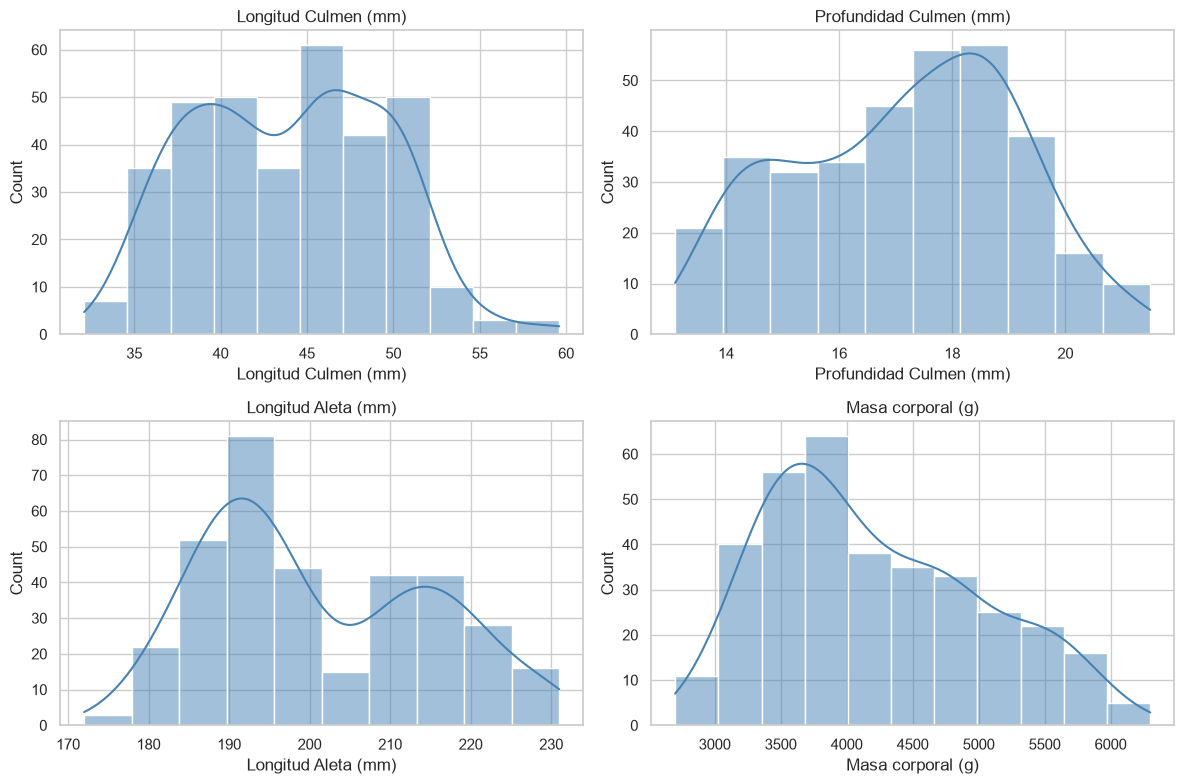

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_columns):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()


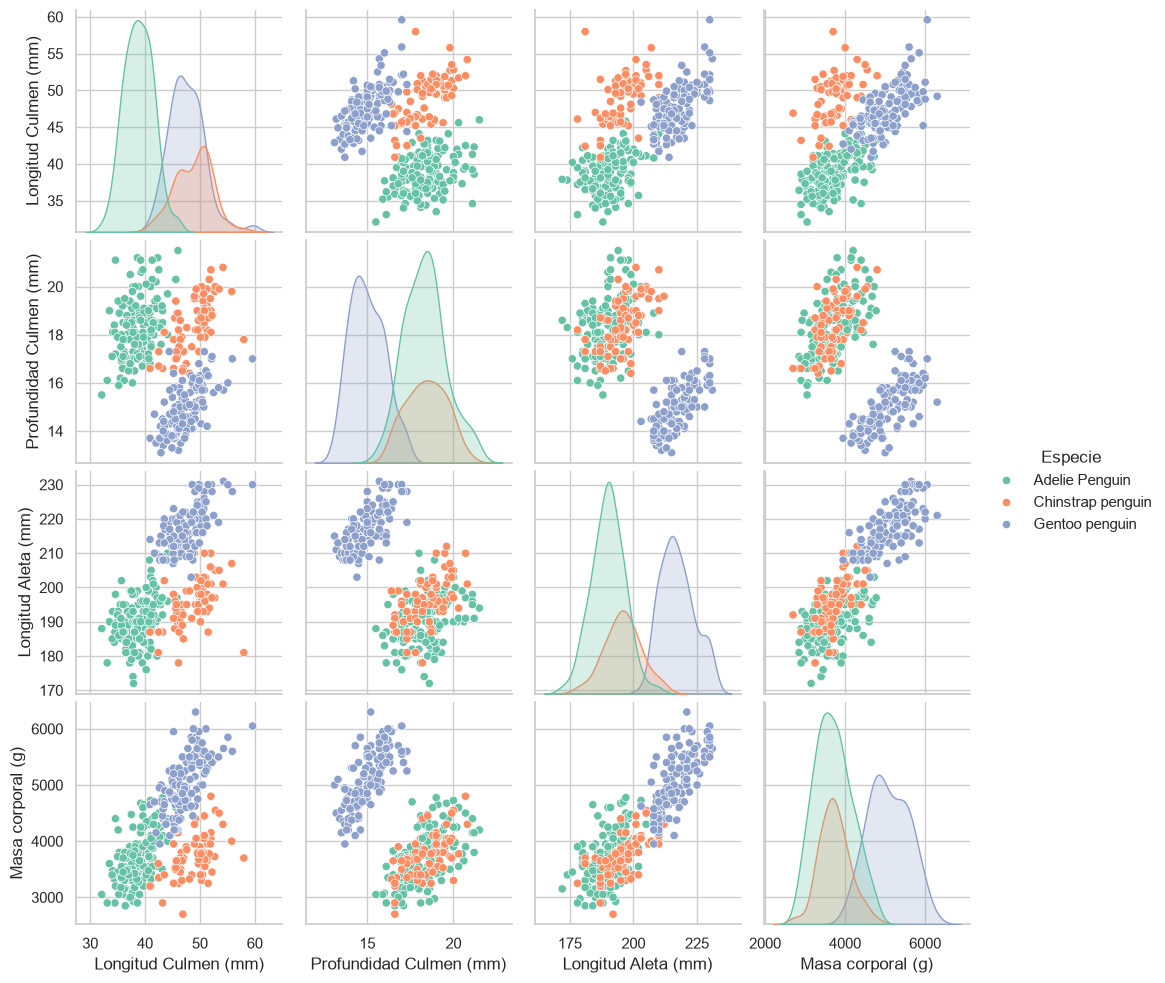

In [62]:
sns.pairplot(df, hue='Especie', palette='Set2', diag_kind='kde')
plt.show()


El `pairplot` muestra que las tres especies se separan con bastante claridad en varias combinaciones de variables, en particular:
- `Longitud Aleta (mm)` vs `Masa corporal (g)`: Gentoo se distingue nítidamente por tener aletas más largas y mayor masa.
- `Longitud Culmen (mm)` vs `Profundidad Culmen (mm)`: separa razonablemente bien a Adelie (culmen corto y profundo) de Chinstrap/Gentoo (culmen más largo).

Esto es una buena señal: las variables morfológicas tienen poder discriminativo respecto de la variable objetivo `Especie`, lo cual será relevante para PCA y los métodos de reducción de dimensionalidad de los puntos siguientes del TP.


# 2. Variación entre variables

## ¿Cuál es la correlación entre las variables? ¿Y con la variable objetivo?

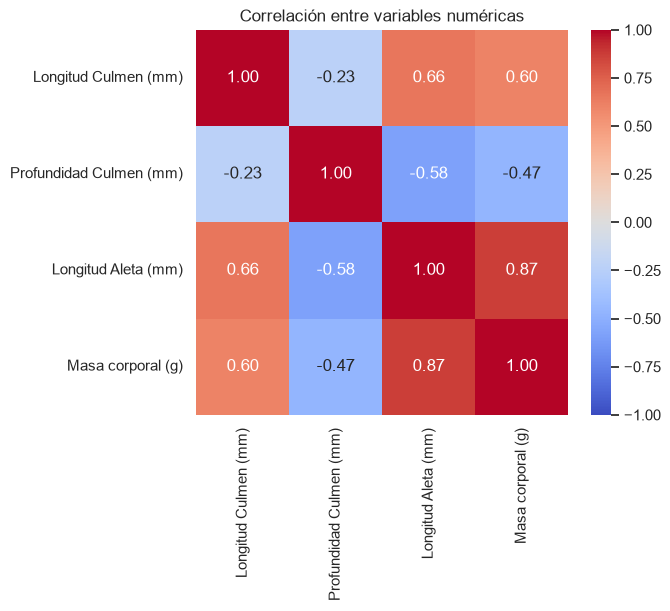

In [63]:
corr = df[num_columns].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlación entre variables numéricas")
plt.show()


- `Longitud Aleta (mm)` y `Masa corporal (g)` presentan una correlación **positiva fuerte** (≈0.87): a mayor tamaño de aleta, mayor masa corporal, algo esperable biológicamente.
- `Profundidad Culmen (mm)` correlaciona **negativamente** con `Longitud Aleta (mm)` y `Masa corporal (g)` (≈-0.58 y -0.47): esto es un efecto de mezcla de especies (Gentoo tiene culmen menos profundo pero aletas más largas y más masa), más que una relación causal dentro de una misma especie.
- `Longitud Culmen (mm)` correlaciona moderadamente y en forma positiva con `Longitud Aleta (mm)` y `Masa corporal (g)` (≈0.65 y 0.59).

Como la variable objetivo (`Especie`) es categórica, la relación con las variables numéricas se analiza mejor de forma visual (boxplots) que con un coeficiente de correlación lineal.

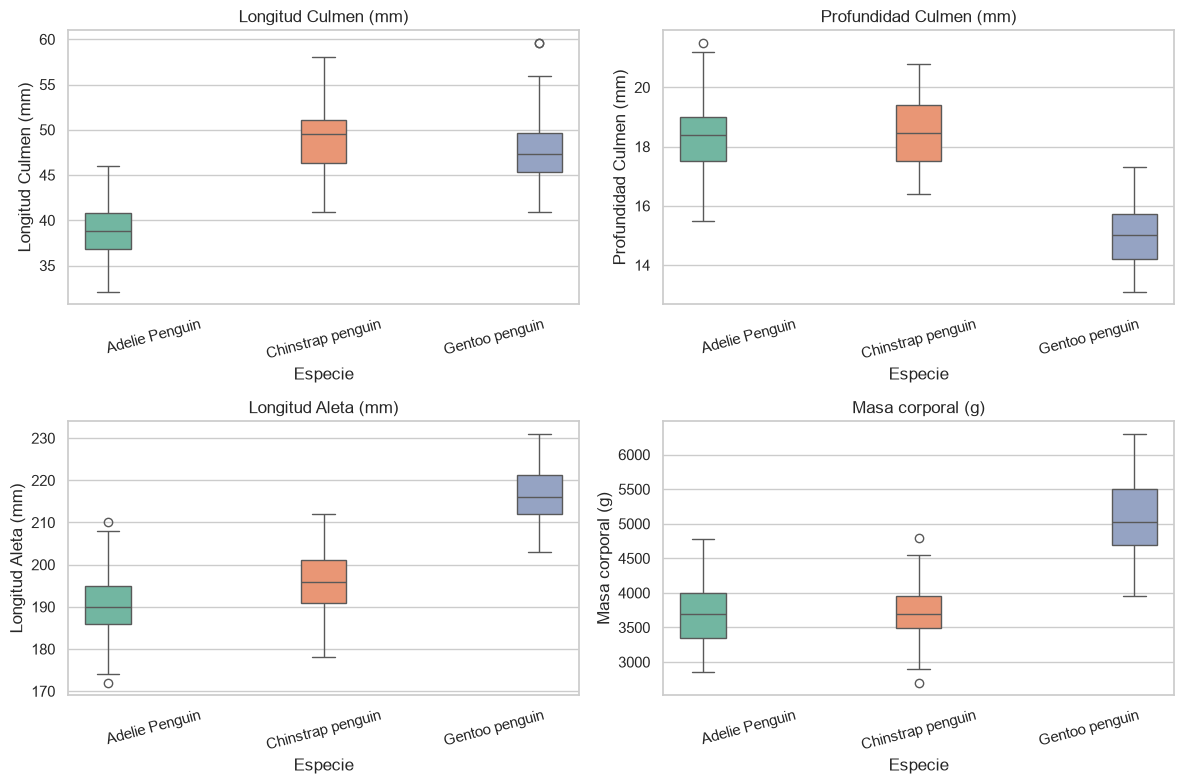

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), num_columns):
    sns.boxplot(data=df, x='Especie', y=col, hue='Especie', palette='Set2', ax=ax, legend=False)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()


Las cuatro variables numéricas muestran diferencias claras en sus medianas entre especies (particularmente `Longitud Aleta` y `Masa corporal` para Gentoo, y `Profundidad Culmen` para separar Adelie de Chinstrap/Gentoo), confirmando que todas aportan información relevante para diferenciar la variable objetivo.

# 3. Limpieza

## ¿Hay errores en los datos? ¿Cómo los corrijo?

Se detectaron dos errores de carga:

1. **`Especie`**: inconsistencia de mayúsculas/minúsculas (`'Adelie Penguin'` vs `'Gentoo penguin'` vs `'Chinstrap penguin'`), que hace que en teoría existan 3 categorías bien definidas pero mal escritas. Se normaliza el texto.
2. **`Sexo`**: existe un valor `'.'` que no corresponde a ninguna categoría válida (`MALE`/`FEMALE`). Se trata como dato faltante.


In [65]:
# 1) Normalizamos el formato de 'Especie'
df['Especie'] = df['Especie'].astype(str).str.strip().str.title().astype('category')
df['Especie'].value_counts()


Especie
Adelie Penguin       154
Gentoo Penguin       125
Chinstrap Penguin     68
Name: count, dtype: int64

In [66]:
# 2) El valor '.' en 'Sexo' es un error de carga -> lo tratamos como nulo
df['Sexo'] = df['Sexo'].astype(str).replace({'.': np.nan, 'nan': np.nan}).astype('category')
df['Sexo'].value_counts(dropna=False)


Sexo
MALE      170
FEMALE    166
NaN        11
Name: count, dtype: int64

## ¿Tiene nulos mi dataset? ¿Cómo los trato? ¿Cómo afecta a los datos mi tratamiento?

In [67]:
df.isna().sum()

Especie                     0
Longitud Culmen (mm)        2
Profundidad Culmen (mm)     2
Longitud Aleta (mm)         2
Masa corporal (g)           2
Sexo                       11
dtype: int64

In [68]:
print("Filas con al menos un nulo:", df.isna().any(axis=1).sum())
df[df.isna().any(axis=1)]

Filas con al menos un nulo: 11


,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
3,Adelie Penguin,NaN,NaN,NaN,NaN,NaN
8,Adelie Penguin,34.1,18.1,193.0,3475.0,NaN
9,Adelie Penguin,42.0,20.2,190.0,4250.0,NaN
10,Adelie Penguin,37.8,17.1,186.0,3300.0,NaN
11,Adelie Penguin,37.8,17.3,180.0,3700.0,NaN
47,Adelie Penguin,37.5,18.9,179.0,2975.0,NaN
248,Gentoo Penguin,44.5,14.3,216.0,4100.0,NaN
289,Gentoo Penguin,46.2,14.4,214.0,4650.0,NaN
327,Gentoo Penguin,47.3,13.8,216.0,4725.0,NaN
339,Gentoo Penguin,44.5,15.7,217.0,4875.0,NaN


Distinguimos dos casos:

1. **Filas totalmente vacías** (todas las variables numéricas y `Sexo` nulas): Hay 2 y no aportan ninguna información y se **eliminan** directamente.
2. **Filas con sólo `Sexo` nulo**: representan una fracción muy pequeña del dataset (9 que son un aprox. 2.6%) y las variables morfológicas sí están presentes. En vez de descartarlas, **imputamos `Sexo` con la moda calculada por especie**, ya que la proporción de machos/hembras puede variar levemente entre especies.

In [69]:
# 1) Eliminamos las filas completamente vacías (sin ningún dato morfológico)
filas_vacias = df[num_columns].isna().all(axis=1)
print("Filas completamente vacías a eliminar:", filas_vacias.sum())

df = df[~filas_vacias].copy()
df.isna().sum()

Filas completamente vacías a eliminar: 2


Especie                    0
Longitud Culmen (mm)       0
Profundidad Culmen (mm)    0
Longitud Aleta (mm)        0
Masa corporal (g)          0
Sexo                       9
dtype: int64

In [70]:
# 2) Imputamos 'Sexo' con la moda por especie
df['Sexo'] = df.groupby('Especie', observed=True)['Sexo'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan))

df.isna().sum()

Especie                    0
Longitud Culmen (mm)       0
Profundidad Culmen (mm)    0
Longitud Aleta (mm)        0
Masa corporal (g)          0
Sexo                       0
dtype: int64

In [71]:
print("Filas finales en el dataset:", len(df))
df['Sexo'].value_counts()


Filas finales en el dataset: 345


Sexo
MALE      174
FEMALE    171
Name: count, dtype: int64

Tras la limpieza, el dataset queda sin valores nulos ni categorías inválidas, conservando el 99.4% de las filas originales (345 de 347).

## ¿Tiene atípicos? ¿Cómo los trato? ¿Cómo afecta a los datos mi tratamiento?

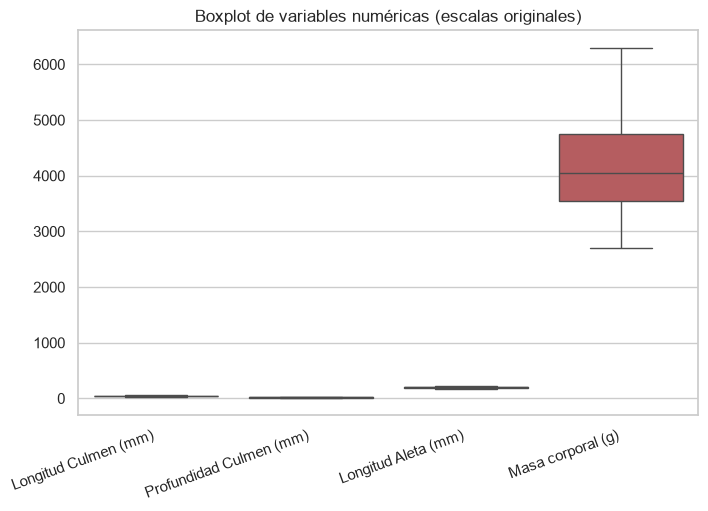

In [72]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df[num_columns])
plt.xticks(rotation=20, ha='right')
plt.title("Boxplot de variables numéricas (escalas originales)")
plt.show()


In [73]:
## Contar cantidad de atípicos por columna (criterio IQR)
for col in num_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Cantidad de atípicos en {col}: {len(outliers)} | {len(outliers)/len(df) * 100:.2f}%")


Cantidad de atípicos en Longitud Culmen (mm): 0 | 0.00%
Cantidad de atípicos en Profundidad Culmen (mm): 0 | 0.00%
Cantidad de atípicos en Longitud Aleta (mm): 0 | 0.00%
Cantidad de atípicos en Masa corporal (g): 0 | 0.00%


Con el criterio de rango intercuartílico (IQR × 1.5) **no se detectan valores atípicos** en ninguna de las cuatro variables numéricas. Esto es consistente con lo observado en los boxplots por especie: la dispersión que se veía "grande" a nivel global (por ejemplo en `Masa corporal` o `Longitud Aleta`) se debe a que estamos mezclando tres especies de tamaños naturalmente distintos, no a errores de medición o valores extremos dentro de cada especie. Por lo tanto, **no es necesario eliminar ni imputar atípicos** en este dataset.

# 4. Codificación de variables categóricas

Nos quedan dos variables categóricas: `Especie` (variable objetivo) y `Sexo` (predictora).

- `Especie`: al ser la variable objetivo, la dejamos en formato texto/categoría para graficar (`hue`) y generamos además una columna numérica auxiliar (`Especie_cod`) por si se necesita como target codificado en los puntos siguientes del TP (PCA, clustering, etc.).
- `Sexo`: es binaria (`MALE` / `FEMALE`), la codificamos con un mapeo simple 0/1.


In [74]:
especie_map = {'Adelie Penguin': 0, 'Chinstrap Penguin': 1, 'Gentoo Penguin': 2}
df['Especie_cod'] = df['Especie'].map(especie_map)


In [75]:
df['Sexo_cod'] = df['Sexo'].map({'MALE': 0, 'FEMALE': 1})
df[['Especie', 'Especie_cod', 'Sexo', 'Sexo_cod']].head()


,Especie,Especie_cod,Sexo,Sexo_cod
0,Adelie Penguin,0,MALE,0
1,Adelie Penguin,0,FEMALE,1
2,Adelie Penguin,0,FEMALE,1
4,Adelie Penguin,0,FEMALE,1
5,Adelie Penguin,0,MALE,0


# 5. Normalización / Estandarización

Las variables numéricas están en escalas muy distintas (mm vs. gramos), por lo que es imprescindible **estandarizarlas** antes de aplicar técnicas sensibles a la escala como PCA, Isomap, t-SNE o K-means (puntos 2 a 6 del TP). Usamos `StandardScaler` (media 0, desvío estándar 1).

In [76]:
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_columns] = scaler.fit_transform(df[num_columns])

df_scaled[num_columns].describe().loc[['mean', 'std']]


,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g)
mean,4.942906e-16,8.650085e-16,-1.647635e-16,-1.647635e-16
std,1.001452e+00,1.001452e+00,1.001452e+00,1.001452e+00


In [77]:
df_scaled.head()

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo,Especie_cod,Sexo_cod
0,Adelie Penguin,-0.880462,0.786509,-1.415974,-0.563913,MALE,0,0
1,Adelie Penguin,-0.807762,0.124690,-1.061003,-0.501806,FEMALE,0,1
2,Adelie Penguin,-0.662362,0.430145,-0.422055,-1.184982,FEMALE,0,1
4,Adelie Penguin,-1.316663,1.091963,-0.564044,-0.936554,FEMALE,0,1
5,Adelie Penguin,-0.844112,1.753782,-0.777027,-0.688126,MALE,0,0


El dataset resultante (`df_scaled`), con las variables numéricas estandarizadas, `Sexo_cod` y `Especie_cod` como versiones numéricas de las categóricas, queda listo como punto de partida para PCA, Isomap, t-SNE, K-means y clustering jerárquico.

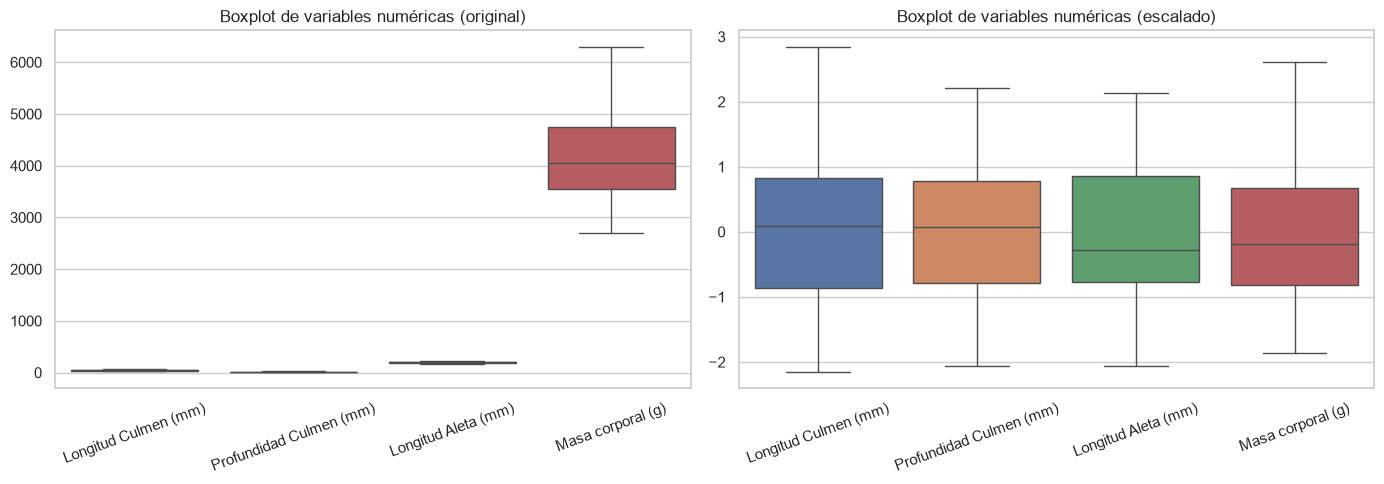

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df[num_columns], ax=axes[0])
axes[0].set_title("Boxplot de variables numéricas (original)")
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df_scaled[num_columns], ax=axes[1])
axes[1].set_title("Boxplot de variables numéricas (escalado)")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# 6. Conclusiones del EDA

- El dataset original tenía **347 filas**, 2 completamente vacías y otras 9 con errores/nulos en `Sexo`; tras la limpieza quedaron **345 filas** sin nulos ni valores inválidos (se perdió menos del 1% de los datos).
- Se corrigieron dos errores de carga: inconsistencia de mayúsculas en `Especie` y el valor inválido `'.'` en `Sexo`.
- No se encontraron valores atípicos (criterio IQR) en ninguna variable numérica: la variabilidad observada responde a la mezcla de tres especies de tamaños distintos, no a errores de medición.
- Las variables morfológicas (`Longitud Aleta`, `Masa corporal` y, en menor medida, `Profundidad Culmen`) muestran buena capacidad para separar visualmente a las tres especies, lo que es una buena señal para las técnicas de reducción de dimensionalidad y clustering de los puntos siguientes.
- Existe correlación fuerte entre `Longitud Aleta` y `Masa corporal` (≈0.87), y correlaciones moderadas/negativas entre `Profundidad Culmen` y el resto, en gran parte explicadas por diferencias entre especies.
- Se codificó `Sexo` (binaria) y se generó una versión numérica de `Especie` para uso posterior, y se estandarizaron las variables numéricas (`df_scaled`) para las próximas etapas del trabajo (PCA, Isomap, t-SNE, K-means y clustering jerárquico).
